In [3]:
from __future__ import annotations
from pathlib import Path
from datetime import datetime
import json, re
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from transformers import AutoTokenizer, AutoModelForCausalLM

# =========================
# CONFIG (EDIT THESE)
# =========================

# Your window tables (already uploaded in this chat; change to your project path when running locally)
WIN_TRAIN = Path("/home/sid/Thesis/project/data/processed/window/windows_train.csv")
WIN_VAL   = Path("/home/sid/Thesis/project/data/processed/window/windows_val.csv")
WIN_TEST  = Path("/home/sid/Thesis/project/data/processed/window/windows_test.csv")

# Whisper CSV directory (must contain <video_id>.csv or similar)
WHISPER_DIR = Path("/home/sid/Thesis/project/data/processed/whisper")  # <-- EDIT
# If your whisper files are nested, we will rglob.

# Where to save unimodal text outputs for fusion
PRED_OUT_ROOT = Path("/home/sid/Thesis/project/data/processed/preds_unimodal")  # <-- EDIT

# Debug outputs (inspect text per window)
DBG_OUT_DIR = Path("/home/sid/Thesis/project/data/processed/llm_window_aligned")  # <-- EDIT
DBG_OUT_DIR.mkdir(parents=True, exist_ok=True)

# LLaMA model snapshot (same style as your llama_pretrain.py)
MODEL_DIR = Path(
    "~/.cache/huggingface/hub/models--meta-llama--Llama-3.2-3B-Instruct/snapshots/0cb88a4f764b7a12671c53f0838cd831a0843b95"
).expanduser().resolve()

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DTYPE  = torch.float16 if DEVICE == "cuda" else torch.float32

# LLM generation settings (as in llama_pretrain.py)
MAX_LEN = 1800
GEN_KW = dict(max_new_tokens=40, do_sample=False)

# Context policy:
# - We DO NOT feed 1s fragments; we build TARGET from an overlapped "speech chunk"
# - and add CONTEXT from preceding turns.
CONTEXT_LOOKBACK_S = 15.0   # gather prior turns within 15s before window start
TARGET_PAD_S = 2.0          # expand window by +/- 2s when collecting target speech
MIN_TEXT_CHARS = 20         # if TARGET shorter, mark present=0

# Overlap rules (borrowed from llm_transcripts_merge.py defaults) :contentReference[oaicite:3]{index=3}
MIN_OVERLAP_MS   = 250
MIN_OVERLAP_FRAC = 0.25
GAP_STOP_MS      = 15000
SAFETY_BUFFER_MS = 300

LABELS = ["MF", "SK", "SJ"]


/home/sid/.local/share/mamba/envs/fex/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
SYSTEM_DE = (
    "Du bist ein sehr genauer und konservativer Annotator für Selbstmitgefühl in reflexiven Interview-Transkripten von Lehrkräften in Ausbildung. "
    "Du antwortest ausschließlich im geforderten JSON-Format."
)

INSTRUCTIONS_DE = """
Klassifiziere NUR den [TARGET]-Abschnitt (nicht den Kontext) eines Interview-Transkripts
mit einer Lehrkraft in Ausbildung.

Labels (0/1, mehrere möglich):
- MF – Achtsamkeit (Mindfulness):
  Nicht-wertendes Wahrnehmen oder Benennen eigener Gedanken/Gefühle (z.B. "ich merke...", "ich war irritiert/überfordert...", "mir ist aufgefallen...").

- SK – Selbstfreundlichkeit (Self-Kindness):
  Explizit verständnisvoller, nachsichtiger oder unterstützender Umgang mit sich selbst
  (z.B. "das ist okay", "ich darf Fehler machen", "ich habe mein Bestes versucht", "ich verzeihe mir", "ich habe Verständnis für mich").

- SJ – Selbstverurteilung / Überidentifikation (Self-Judgment / Over-identification):
  Harte Selbstkritik, Schuldzuweisung oder Abwertung der eigenen Person (z.B. "ich bin unfähig", "ich habe versagt", starkes Grübeln/Feststecken).

Regeln:
- Kein Label nur wegen Ereignissen oder Handlungen vergeben;
  ein Label nur bei expliziten sprachlichen Hinweisen im [TARGET], die zur Definition passen.
- Wenn der [TARGET]-Text zu kurz oder inhaltlich leer ist (z.B. nur Füllwörter wie "äh", "hm", "ja", "okay"),
  setze alle Labels auf 0 und conf auf 0.2.
- Vergib ein Label nur bei klarer, expliziter Evidenz im [TARGET]; bei Unsicherheit setze 0.
- Pausen/Disfluenz wie (.), (..), (...), [pause], [lacht], "äh", "hm" zählen nur, wenn sie direkt mit innerem Erleben oder Selbstbewertung im [TARGET] zusammen auftreten.
  Pausen allein sind kein Label; wenn unklar, ignoriere sie.
- Wenn keine Kategorie zutrifft, setze alle Labels auf 0.

Zusätzlich:
- "conf" ∈ {0.2, 0.5, 0.8}
  0.8 = klare, explizite Evidenz im [TARGET]
  0.5 = teilweise Evidenz, aber nicht sehr stark
  0.2 = unsicher / zu kurz / unklar

Antwort AUSSCHLIESSLICH als JSON:
{"MF":0,"SK":0,"SJ":0,"conf":0.2}
""".strip()

def build_prompt_de(model_input: str) -> str:
    return f"{INSTRUCTIONS_DE}\n\nTEXT:\n{model_input}\n"

_JSON_RE_ALL = re.compile(r"\{[^{}]*\}", re.DOTALL)

def parse_json_from_text(text: str) -> dict:
    """
    Parses the LAST JSON object from generation.
    Returns defaults if parsing fails.
    """
    matches = _JSON_RE_ALL.findall(text)
    if not matches:
        return {"MF": 0, "SK": 0, "SJ": 0, "conf": 0.2}

    try:
        obj = json.loads(matches[-1])
    except Exception:
        return {"MF": 0, "SK": 0, "SJ": 0, "conf": 0.2}

    def as01(v):
        s = str(v).strip().lower()
        return int(s in {"1", "true", "ja"})

    def as_conf(v):
        # accept numeric or strings; clamp into {0.2,0.5,0.8}
        try:
            x = float(v)
        except Exception:
            return 0.2
        if x >= 0.7:
            return 0.8
        if x >= 0.35:
            return 0.5
        return 0.2

    return {
        "MF": as01(obj.get("MF", 0)),
        "SK": as01(obj.get("SK", 0)),
        "SJ": as01(obj.get("SJ", 0)),
        "conf": as_conf(obj.get("conf", 0.2)),
    }

In [6]:
tok = AutoTokenizer.from_pretrained(MODEL_DIR, use_fast=True, local_files_only=True)
tok.truncation_side = "left"
if tok.pad_token is None:
    tok.pad_token = tok.eos_token

model = AutoModelForCausalLM.from_pretrained(
    MODEL_DIR,
    torch_dtype=DTYPE,
    device_map="auto" if DEVICE == "cuda" else None,
    local_files_only=True,
)
model.eval()
model.config.use_cache = True

print("Loaded model on:", model.device)


`torch_dtype` is deprecated! Use `dtype` instead!
Loading checkpoint shards: 100%|██████████| 2/2 [00:01<00:00,  1.43it/s]
Some parameters are on the meta device because they were offloaded to the cpu.


Loaded model on: cuda:0


In [7]:
def load_windows_csv(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path)
    required = ["video_id", "w_start", "w_end", "w_center"]
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"{path} missing {missing}. Columns: {list(df.columns)}")
    df["video_id"] = df["video_id"].astype(str)
    return df

win_train = load_windows_csv(WIN_TRAIN)
win_val   = load_windows_csv(WIN_VAL)
win_test  = load_windows_csv(WIN_TEST)

print("windows:", len(win_train), len(win_val), len(win_test))
print(win_train.head(2))


windows: 24249 3450 4275
  video_id  w_start   w_end  w_center  y_MF  mask_MF  y_SK  mask_SK  y_SJ  \
0  MP00036    656.0   660.0     658.0   0.0        1   0.0        1   0.0   
1  MP00053   2789.0  2793.0    2791.0   1.0        1   0.0        0   0.0   

   mask_SJ  mask_any  split  is_bg_negative  
0        1         0  train               1  
1        0         1  train               0  


In [6]:
CSV_START_COL = "start"
CSV_END_COL   = "end"
CSV_TEXT_COL  = "text"
CSV_SPK_COL   = "speaker"
CSV_TYPE_COL  = "type"
CSV_KEEP_TYPE = "speech"

def find_whisper_csv(video_id: str) -> Path | None:
    direct = WHISPER_DIR / f"{video_id}.csv"
    if direct.exists():
        return direct
    hits = list(WHISPER_DIR.rglob(f"{video_id}.csv"))
    return hits[0] if hits else None

def prepare_speech_df(csv_path: Path) -> pd.DataFrame:
    df = pd.read_csv(csv_path)

    if CSV_TYPE_COL in df.columns:
        df = df[df[CSV_TYPE_COL].astype(str) == CSV_KEEP_TYPE]

    df = df[df[CSV_TEXT_COL].notna()]
    df[CSV_TEXT_COL] = df[CSV_TEXT_COL].astype(str).str.strip()
    df = df[df[CSV_TEXT_COL] != ""]

    # seconds -> ms
    df["start_ms"] = (df[CSV_START_COL].astype(float) * 1000).round().astype(int)
    df["end_ms"]   = (df[CSV_END_COL].astype(float) * 1000).round().astype(int)

    if CSV_SPK_COL not in df.columns:
        df[CSV_SPK_COL] = "UNKNOWN"

    out = df[["start_ms", "end_ms", CSV_TEXT_COL, CSV_SPK_COL]].copy()
    out = out.rename(columns={CSV_TEXT_COL: "text", CSV_SPK_COL: "speaker"})
    return out.sort_values(["start_ms", "end_ms"]).reset_index(drop=True)

def _overlap_ms(a0, a1, b0, b1):
    return max(0, min(a1, b1) - max(a0, b0))

def pause_token(gap_ms: int) -> str:
    if gap_ms < 300:
        return ""
    if gap_ms < 800:
        return "(.)"
    if gap_ms < 1500:
        return "(..)"
    return "(...)"

def join_with_pauses(rows: list[dict]) -> str:
    if not rows:
        return ""
    out = [rows[0]["text"].strip()]
    for prev, cur in zip(rows, rows[1:]):
        gap = cur["start_ms"] - prev["end_ms"]
        p = pause_token(gap)
        if p:
            out.append(p)
        out.append(cur["text"].strip())
    return " ".join(out).strip()

def build_context_and_target_for_window(
    speech_df: pd.DataFrame,
    w_start_s: float,
    w_end_s: float,
    lookback_s: float = CONTEXT_LOOKBACK_S,
    target_pad_s: float = TARGET_PAD_S,
):
    """
    Returns (context_text, target_text, target_speaker, target_span_ms)
    Crucially: TARGET is not 1s fragment; it is the joined speech units overlapping [w_start - pad, w_end + pad].
    CONTEXT pulls previous turns for the target speaker + the other speaker.
    """
    S_ms = int(round((w_start_s - target_pad_s) * 1000))
    E_ms = int(round((w_end_s   + target_pad_s) * 1000))
    S_ms = max(0, S_ms)

    # pick overlapping rows with sufficient overlap
    t_units = []
    overlaps = []
    for _, r in speech_df.iterrows():
        ov = _overlap_ms(int(r.start_ms), int(r.end_ms), S_ms, E_ms)
        if ov <= 0:
            continue
        dur = max(1, int(r.end_ms) - int(r.start_ms))
        if ov >= MIN_OVERLAP_MS or ov >= MIN_OVERLAP_FRAC * dur:
            t_units.append(r)
            overlaps.append(ov)

    if not t_units:
        return "", "", None, (S_ms, E_ms)

    # choose dominant speaker in target span
    spk_weight = {}
    for r, ov in zip(t_units, overlaps):
        spk_weight[r.speaker] = spk_weight.get(r.speaker, 0) + ov
    target_speaker = max(spk_weight, key=spk_weight.get)

    # build target from all overlapped units (keeps meaning)
    target_rows = [dict(start_ms=int(r.start_ms), end_ms=int(r.end_ms), text=str(r.text)) for r in t_units]
    target_text = join_with_pauses(target_rows)

    # build context: prior turns within lookback seconds, ending before window start - safety buffer
    cutoff = int(round(w_start_s * 1000)) - SAFETY_BUFFER_MS
    lookback_cut = cutoff - int(round(lookback_s * 1000))

    prev = speech_df[(speech_df.end_ms <= cutoff) & (speech_df.end_ms >= lookback_cut)]
    if prev.empty:
        return "", target_text, target_speaker, (S_ms, E_ms)

    prev_rows = prev.to_dict("records")

    # pick last block from target speaker
    idx = len(prev_rows) - 1
    while idx >= 0 and prev_rows[idx]["speaker"] != target_speaker:
        idx -= 1

    participant, interviewer = [], []
    if idx >= 0:
        # collect contiguous target-speaker block backwards
        participant = [prev_rows[idx]]
        i = idx - 1
        while i >= 0 and prev_rows[i]["speaker"] == target_speaker:
            if participant[0]["start_ms"] - prev_rows[i]["end_ms"] > GAP_STOP_MS:
                break
            participant.insert(0, prev_rows[i])
            i -= 1

        # collect one contiguous block of the other speaker immediately preceding
        if i >= 0:
            other = prev_rows[i]["speaker"]
            interviewer = [prev_rows[i]]
            j = i - 1
            while j >= 0 and prev_rows[j]["speaker"] == other:
                if interviewer[0]["start_ms"] - prev_rows[j]["end_ms"] > GAP_STOP_MS:
                    break
                interviewer.insert(0, prev_rows[j])
                j -= 1

    context_text = join_with_pauses(interviewer + participant)
    return context_text, target_text, target_speaker, (S_ms, E_ms)

def make_model_input(context_text: str, target_text: str) -> str:
    if context_text:
        return f"[CONTEXT]\n{context_text}\n\n[TARGET]\n{target_text}"
    return f"[TARGET]\n{target_text}"


In [7]:
import hashlib

@torch.no_grad()
def llm_predict_labels(model_input: str) -> tuple[dict, str]:
    prompt = build_prompt_de(model_input)
    msgs = [
        {"role": "system", "content": SYSTEM_DE},
        {"role": "user", "content": prompt},
    ]
    input_text = tok.apply_chat_template(msgs, tokenize=False, add_generation_prompt=True)
    inputs = tok(
        input_text,
        return_tensors="pt",
        truncation=True,
        max_length=MAX_LEN,
    ).to(model.device)

    out = model.generate(**inputs, **GEN_KW)
    gen = tok.decode(out[0, inputs["input_ids"].shape[1]:], skip_special_tokens=True).strip()
    parsed = parse_json_from_text(gen)
    return parsed, gen

def pred_to_probs_and_conf(parsed: dict) -> tuple[np.ndarray, float]:
    """
    Convert (MF/SK/SJ, conf) -> soft probabilities for fusion.
    We intentionally keep it coarse/stable.
    """
    conf = float(parsed.get("conf", 0.2))

    # map conf bins to hi/lo
    if conf >= 0.8:
        hi, lo = 0.95, 0.05
    elif conf >= 0.5:
        hi, lo = 0.85, 0.15
    else:
        hi, lo = 0.70, 0.30

    probs = np.array([
        hi if parsed.get("MF", 0) == 1 else lo,
        hi if parsed.get("SK", 0) == 1 else lo,
        hi if parsed.get("SJ", 0) == 1 else lo,
    ], dtype=np.float32)

    return probs, conf


def chunk_key(video_id: str, span_ms: tuple[int,int], target_text: str) -> str:
    h = hashlib.md5(target_text.encode("utf-8", errors="ignore")).hexdigest()[:10]
    return f"{video_id}__{span_ms[0]}_{span_ms[1]}__{h}"

def run_window_aligned_text(split_name: str, win_df: pd.DataFrame):
    # transcript cache per video_id
    speech_cache = {}
    missing_csv = set()

    N = len(win_df)
    probs = np.zeros((N, 3), dtype=np.float32)
    present = np.zeros((N,), dtype=np.float32)
    conf_text = np.zeros((N,), dtype=np.float32)  # NEW

    dbg_rows = []

    pred_cache = {}  # chunk_id -> (probs[3], conf, parsed, raw_generation)
    n_calls = 0

    for i, row in win_df.reset_index(drop=True).iterrows():
        vid = str(row["video_id"])
        w0 = float(row["w_start"])
        w1 = float(row["w_end"])

        # load transcript for this vid
        if vid not in speech_cache and vid not in missing_csv:
            csv_path = find_whisper_csv(vid)
            if csv_path is None:
                missing_csv.add(vid)
            else:
                speech_cache[vid] = prepare_speech_df(csv_path)

        if vid in missing_csv:
            # no transcript
            probs[i] = np.array([0.30, 0.30, 0.30], dtype=np.float32)
            present[i] = 0.0
            conf_text[i] = 0.0
            dbg_rows.append({
                "row_idx": i, "video_id": vid, "w_start": w0, "w_end": w1,
                "present_text": 0, "conf": 0.0,
                "context_text": "", "target_text": "",
                "p_MF": 0.30, "p_SK": 0.30, "p_SJ": 0.30,
                "raw_generation": ""
            })
            continue

        speech_df = speech_cache[vid]
        ctx, tgt, spk, span_ms = build_context_and_target_for_window(speech_df, w0, w1)

        # decide presence
        if tgt is None or len(str(tgt).strip()) < MIN_TEXT_CHARS:
            probs[i] = np.array([0.30, 0.30, 0.30], dtype=np.float32)
            present[i] = 0.0
            conf_text[i] = 0.0
            dbg_rows.append({
                "row_idx": i, "video_id": vid, "w_start": w0, "w_end": w1,
                "present_text": 0, "conf": 0.0,
                "context_text": ctx, "target_text": tgt,
                "p_MF": 0.30, "p_SK": 0.30, "p_SJ": 0.30,
                "raw_generation": ""
            })
            continue

        present[i] = 1.0
        model_input = make_model_input(ctx, tgt)
        ck = chunk_key(vid, span_ms, tgt)

        if ck not in pred_cache:
            parsed, gen = llm_predict_labels(model_input)
            p, conf = pred_to_probs_and_conf(parsed)
            pred_cache[ck] = (p, conf, parsed, gen)
            n_calls += 1

        p, conf, parsed, gen = pred_cache[ck]
        probs[i] = p
        conf_text[i] = conf

        dbg_rows.append({
            "row_idx": i, "video_id": vid, "w_start": w0, "w_end": w1,
            "present_text": 1, "conf": float(conf),
            "target_speaker": spk or "",
            "context_text": ctx, "target_text": tgt,
            "chunk_id": ck,
            "MF_hat": int(parsed.get("MF", 0)),
            "SK_hat": int(parsed.get("SK", 0)),
            "SJ_hat": int(parsed.get("SJ", 0)),
            "p_MF": float(p[0]), "p_SK": float(p[1]), "p_SJ": float(p[2]),
            "raw_generation": gen[:3000],
        })

        if (i + 1) % 2000 == 0:
            print(f"[{split_name}] {i+1}/{N} | LLM calls: {n_calls} | unique chunks: {len(pred_cache)}")

    dbg = pd.DataFrame(dbg_rows)
    info = {
        "n_llm_calls": n_calls,
        "n_unique_chunks": len(pred_cache),
        "n_missing_csv": len(missing_csv),
    }
    return probs, present, conf_text, dbg, info


    dbg = pd.DataFrame(dbg_rows)
    return probs, present, dbg, {"n_llm_calls": n_calls, "n_unique_chunks": len(pred_cache), "n_missing_csv": len(missing_csv)}


In [8]:
ts = datetime.now().strftime("%Y%m%d_%H%M%S")

def save_for_fusion(split: str, probs: np.ndarray, present: np.ndarray, conf_text: np.ndarray):
    out = PRED_OUT_ROOT / split / "text"
    out.mkdir(parents=True, exist_ok=True)

    np.save(out / f"probs_{split}.npy", probs.astype(np.float32))
    np.save(out / f"present_{split}.npy", present.astype(np.float32).reshape(-1))
    np.save(out / f"conf_{split}.npy", conf_text.astype(np.float32).reshape(-1))


# TRAIN
p_tr, pr_tr, conf_tr, dbg_tr, info_tr = run_window_aligned_text("train", win_train)
save_for_fusion("train", p_tr, pr_tr, conf_tr)
dbg_tr.to_csv(DBG_OUT_DIR / f"dbg_text_windows_train_{ts}.csv", index=False)
print("train info:", info_tr)

# VAL
p_va, pr_va, conf_va, dbg_va, info_va = run_window_aligned_text("val", win_val)
save_for_fusion("val", p_va, pr_va, conf_va)
dbg_va.to_csv(DBG_OUT_DIR / f"dbg_text_windows_val_{ts}.csv", index=False)
print("val info:", info_va)

# TEST
p_te, pr_te, conf_te, dbg_te, info_te = run_window_aligned_text("test", win_test)
save_for_fusion("test", p_te, pr_te, conf_te)
dbg_te.to_csv(DBG_OUT_DIR / f"dbg_text_windows_test_{ts}.csv", index=False)
print("test info:", info_te)

print("✅ Saved fusion-ready text outputs to:", PRED_OUT_ROOT)
print("✅ Debug CSVs:", DBG_OUT_DIR)



The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for op

[train] 2000/24249 | LLM calls: 1468 | unique chunks: 1468


Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for

[train] 4000/24249 | LLM calls: 2941 | unique chunks: 2941


Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for

...

[test] 2000/4275 | LLM calls: 1552 | unique chunks: 1552


Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for

[test] 4000/4275 | LLM calls: 3084 | unique chunks: 3084


Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for

test info: {'n_llm_calls': 3295, 'n_unique_chunks': 3295, 'n_missing_csv': 0}
✅ Saved fusion-ready text outputs to: /home/sid/Thesis/project/data/processed/preds_unimodal
✅ Debug CSVs: /home/sid/Thesis/project/data/processed/llm_window_aligned


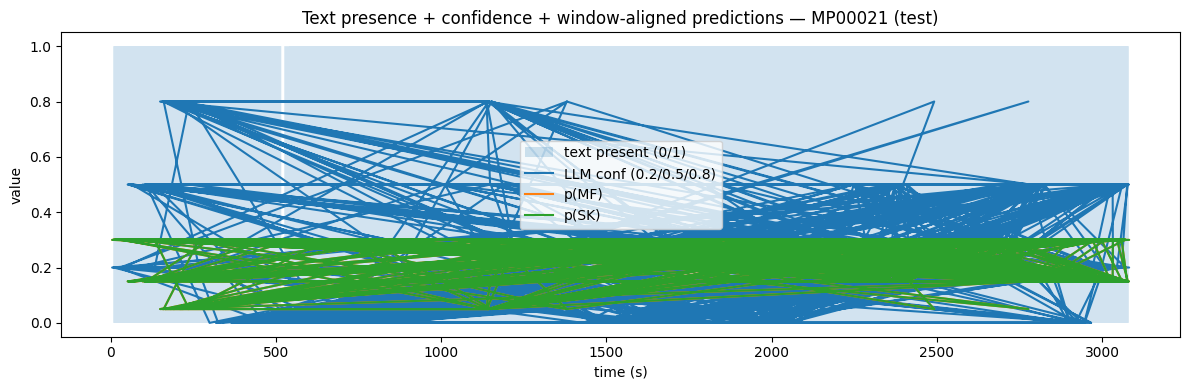

[OK] Saved figure -> /home/sid/Thesis/project/data/processed/llm_window_aligned/figs/text_timeline_test_MP00021.png


PosixPath('/home/sid/Thesis/project/data/processed/llm_window_aligned/figs/text_timeline_test_MP00021.png')

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path


def plot_text_presence_conf_and_probs_from_disk(
    split: str = "test",
    video_id: str | None = None,
    win_dir: str = "/home/sid/Thesis/project/data/processed/window",
    preds_root: str = "/home/sid/Thesis/project/data/processed/preds_unimodal",
    modality: str = "text",
    out_dir: str = "/home/sid/Thesis/project/data/processed/llm_window_aligned/figs",
    title_suffix: str | None = None,
    plot_labels: tuple[bool, bool, bool] = (True, True, False),  # (MF, SK, SJ)
    dpi: int = 200,
):
    """
    Loads windows_{split}.csv and unimodal text outputs from preds_unimodal/{split}/text/,
    then plots presence + confidence + probs over time for one video_id and saves a PNG.

    Required files:
      {win_dir}/windows_{split}.csv
      {preds_root}/{split}/{modality}/probs_{split}.npy      shape [N,3]
      {preds_root}/{split}/{modality}/present_{split}.npy    shape [N]
      {preds_root}/{split}/{modality}/conf_{split}.npy       shape [N]
    """
    win_dir = Path(win_dir)
    preds_root = Path(preds_root)
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    # ---- load windows
    win_path = win_dir / f"windows_{split}.csv"
    if not win_path.exists():
        raise FileNotFoundError(f"Missing windows file: {win_path}")
    win_df = pd.read_csv(win_path)

    # sanity: required columns
    for c in ["video_id", "w_start", "w_end"]:
        if c not in win_df.columns:
            raise ValueError(f"{win_path} missing column '{c}'. Found: {list(win_df.columns)}")

    # ---- load predictions
    pred_dir = preds_root / split / modality
    probs_path = pred_dir / f"probs_{split}.npy"
    pres_path  = pred_dir / f"present_{split}.npy"
    conf_path  = pred_dir / f"conf_{split}.npy"

    for p in [probs_path, pres_path, conf_path]:
        if not p.exists():
            raise FileNotFoundError(f"Missing required prediction file: {p}")

    probs = np.load(probs_path)       # [N,3]
    present = np.load(pres_path)      # [N]
    conf = np.load(conf_path)         # [N]

    # ---- length check
    N = len(win_df)
    if probs.shape != (N, 3):
        raise ValueError(f"probs shape {probs.shape} != expected {(N,3)} (row-order mismatch?)")
    if present.shape[0] != N or conf.shape[0] != N:
        raise ValueError(f"present/conf lengths must be {N}. Got {present.shape}, {conf.shape}")

    # ---- choose video
    if video_id is None:
        video_id = str(win_df["video_id"].astype(str).iloc[0])
    else:
        video_id = str(video_id)

    m = (win_df["video_id"].astype(str) == video_id).to_numpy()
    if m.sum() == 0:
        raise ValueError(f"No rows for video_id='{video_id}' in {win_path}")

    t = win_df.loc[m, "w_start"].to_numpy()
    pres = present[m]
    cf = conf[m]
    p = probs[m]

    # ---- plot
    plt.figure(figsize=(12, 4))
    plt.fill_between(t, 0, pres, step="pre", alpha=0.2, label="text present (0/1)")
    plt.plot(t, cf, label="LLM conf (0.2/0.5/0.8)")

    if plot_labels[0]:
        plt.plot(t, p[:, 0], label="p(MF)")
    if plot_labels[1]:
        plt.plot(t, p[:, 1], label="p(SK)")
    if plot_labels[2]:
        plt.plot(t, p[:, 2], label="p(SJ)")

    plt.ylim(-0.05, 1.05)
    plt.xlabel("time (s)")
    plt.ylabel("value")

    if title_suffix is None:
        title_suffix = f"({split})"
    plt.title(f"Text presence + confidence + window-aligned predictions — {video_id} {title_suffix}")

    plt.legend()
    plt.tight_layout()

    # ---- save
    fname = f"text_timeline_{split}_{video_id}.png".replace("/", "_")
    out_path = out_dir / fname
    plt.savefig(out_path, dpi=dpi, bbox_inches="tight")
    plt.show()

    print(f"[OK] Saved figure -> {out_path}")
    return out_path


# === Example usage (immediately after you saved preds_unimodal outputs) ===
# 1) Plot + save first test video
plot_text_presence_conf_and_probs_from_disk(
    split="test",
    video_id=None,  # auto-pick first
    plot_labels=(True, True, False),  # MF + SK only
)

# 2) Plot + save a specific video (uncomment and set id)
# plot_text_presence_conf_and_probs_from_disk(split="test", video_id="MP_00023", plot_labels=(True, True, True))


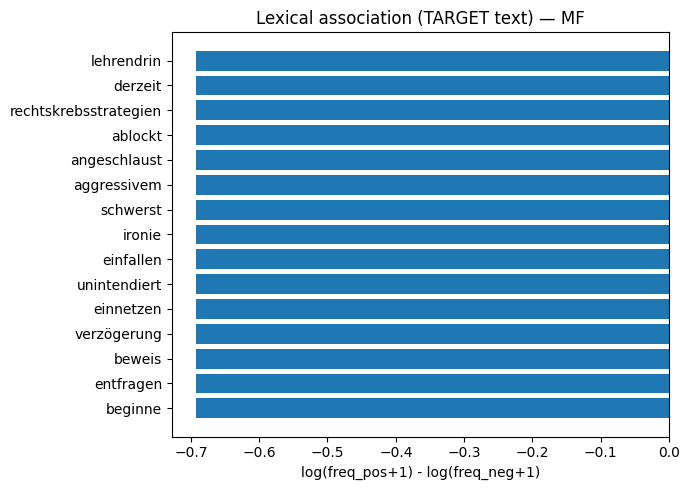

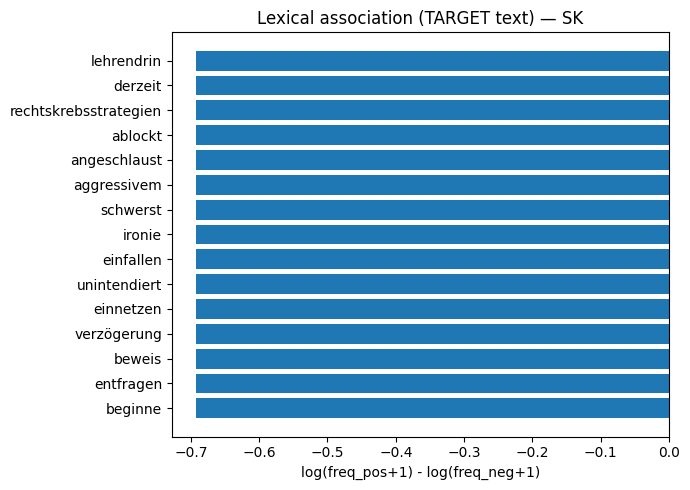

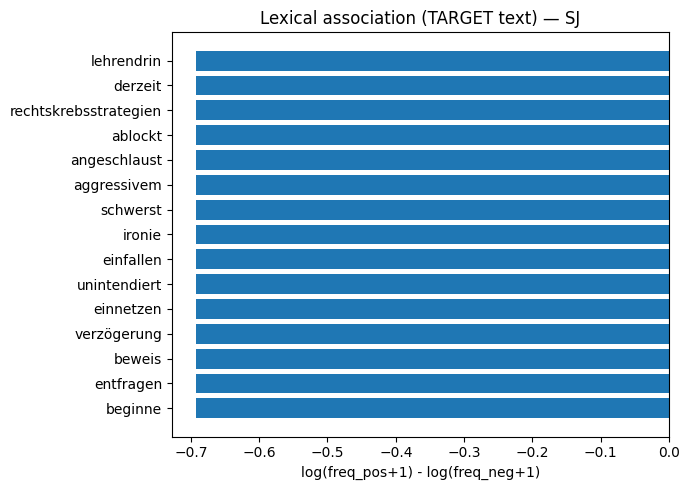

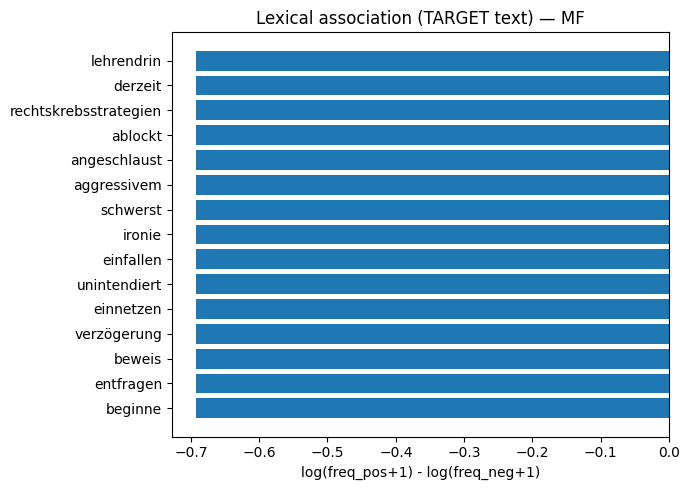

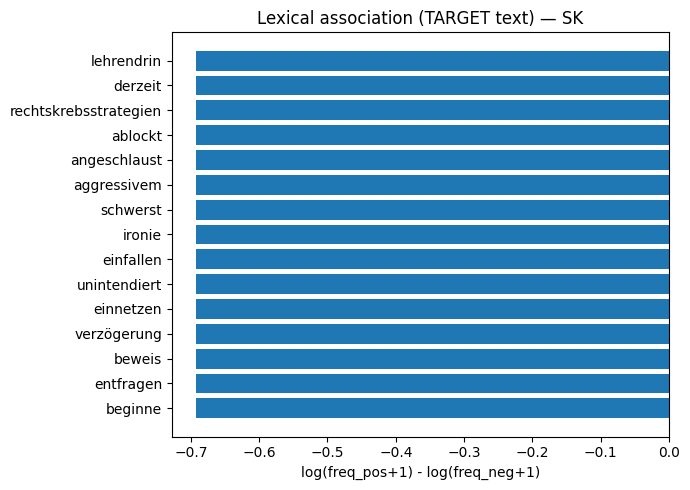

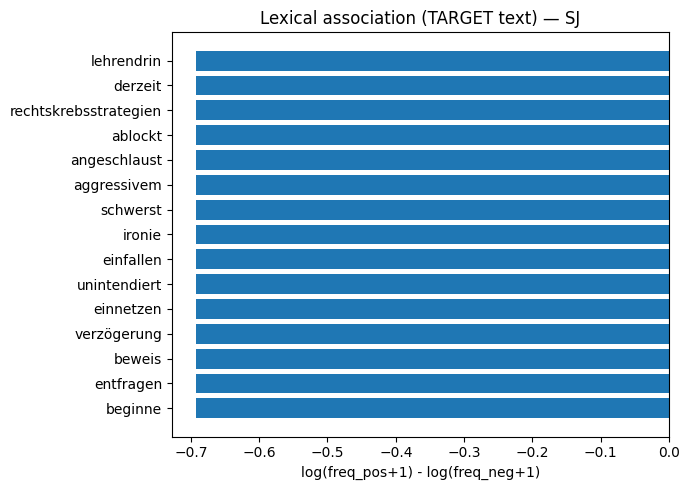

In [14]:
import numpy as np
from collections import Counter
import re
import matplotlib.pyplot as plt

def tokenize_simple(text: str):
    text = text.lower()
    text = re.sub(r"[^a-zäöüß0-9\s]", " ", text)
    return [t for t in text.split() if len(t) >= 3]

def top_lexical_contrast(dbg_df: pd.DataFrame, label: str, topk=20):
    col = f"{label}_hat"
    if col not in dbg_df.columns:
        raise ValueError(f"Expected column '{col}' in dbg_df. Found: {list(dbg_df.columns)[:30]}")

    # Use TARGET text only (meaning unit)
    pos = dbg_df[dbg_df[col] == 1]
    neg = dbg_df[dbg_df[col] == 0]

    c_pos, c_neg = Counter(), Counter()
    for txt in pos["target_text"].fillna("").astype(str):
        c_pos.update(tokenize_simple(txt))
    for txt in neg["target_text"].fillna("").astype(str):
        c_neg.update(tokenize_simple(txt))

    vocab = set(c_pos) | set(c_neg)
    scores = []
    for w in vocab:
        a = c_pos[w] + 1
        b = c_neg[w] + 1
        scores.append((w, np.log(a) - np.log(b), c_pos[w], c_neg[w]))

    scores.sort(key=lambda x: x[1], reverse=True)
    return scores[:topk]

def plot_top_words(scores, label):
    words = [s[0] for s in scores][::-1]
    vals  = [s[1] for s in scores][::-1]
    plt.figure(figsize=(7, 5))
    plt.barh(words, vals)
    plt.title(f"Lexical association (TARGET text) — {label}")
    plt.xlabel("log(freq_pos+1) - log(freq_neg+1)")
    plt.tight_layout()
    plt.show()

dbg_all = pd.concat([dbg_tr, dbg_va], ignore_index=True)
for lab in ["MF", "SK", "SJ"]:
    scores = top_lexical_contrast(dbg_all, lab, topk=15)
    plot_top_words(scores, lab)


# Use one split debug df; you can also concatenate train+val for stability
dbg_all = pd.concat([dbg_tr, dbg_va], ignore_index=True)
for lab in ["MF","SK","SJ"]:
    scores = top_lexical_contrast(dbg_all, lab, topk=15)
    plot_top_words(scores, lab)


In [15]:
def error_buckets(win_df, dbg_df, probs, label: str, topn=20):
    # align via row_idx
    df = dbg_df.copy()
    # merge ground truth from windows
    gt = win_df[[ "video_id","w_start","w_end", f"y_{label}" ]].copy().reset_index(drop=True)
    gt["row_idx"] = np.arange(len(gt))
    df = df.merge(gt[["row_idx", f"y_{label}"]], on="row_idx", how="left")

    # predicted hard label from probs (since our probs are 0.9/0.1)
    j = {"MF":0,"SK":1,"SJ":2}[label]
    df[f"p_{label}"] = probs[df["row_idx"].to_numpy(), j]
    df[f"pred_{label}"] = (df[f"p_{label}"] >= 0.5).astype(int)

    fp = df[(df[f"y_{label}"] == 0) & (df[f"pred_{label}"] == 1)].sort_values(f"p_{label}", ascending=False).head(topn)
    fn = df[(df[f"y_{label}"] == 1) & (df[f"pred_{label}"] == 0)].sort_values(f"p_{label}", ascending=True).head(topn)

    return fp[["video_id","w_start","w_end",f"y_{label}",f"p_{label}","target_text"]], fn[["video_id","w_start","w_end",f"y_{label}",f"p_{label}","target_text"]]

fp_mf, fn_mf = error_buckets(win_test, dbg_te, p_te, "MF", topn=10)
display(fp_mf)
display(fn_mf)


,video_id,w_start,w_end,y_MF,p_MF,target_text


,video_id,w_start,w_end,y_MF,p_MF,target_text
233,MP00005,4323.0,4327.0,1.0,0.05,"Für den Fall, dass es halt wirklich was..."
3959,MP00041,3255.0,3259.0,1.0,0.05,"Und natürlich auch irgendwo dieses Okay, ..."
4018,MP00014,1463.0,1467.0,1.0,0.05,Wahrscheinlich hätte ich meine Stimme ein...
3823,MP00041,3257.0,3261.0,1.0,0.05,"Und natürlich auch irgendwo dieses Okay, ..."
3905,MP00014,1462.0,1466.0,1.0,0.05,Wahrscheinlich hätte ich meine Stimme ein...
3765,MP00021,1153.0,1157.0,1.0,0.05,"Ja, macht man ja öfter, wenn irgendwas ..."
3562,MP00021,1142.0,1146.0,1.0,0.05,"Ja, macht man ja öfter, wenn irgendwas ..."
3554,MP00041,3256.0,3260.0,1.0,0.05,"Und natürlich auch irgendwo dieses Okay, ..."
3601,MP00021,1137.0,1141.0,1.0,0.05,"Ja, okay, da war ich erstmal geschockt, ..."
239,MP00005,4322.0,4326.0,1.0,0.05,"Für den Fall, dass es halt wirklich was..."
